In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

In [22]:
train_path = "../dataset/train"
val_path = "../dataset/val"
test_path = "../dataset/test"

In [23]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

In [26]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(48,48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(48,48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(48,48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.


In [27]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 67ms/step - accuracy: 0.2710 - loss: 1.7652 - val_accuracy: 0.3695 - val_loss: 1.6216
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.3600 - loss: 1.6222 - val_accuracy: 0.4452 - val_loss: 1.4420
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4231 - loss: 1.5007 - val_accuracy: 0.4762 - val_loss: 1.3593
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4513 - loss: 1.4290 - val_accuracy: 0.4937 - val_loss: 1.3145
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4687 - loss: 1.3900 - val_accuracy: 0.5102 - val_loss: 1.2847
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4840 - loss: 1.3507 - val_accuracy: 0.5180 - val_loss: 1.2554
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4932 - loss: 1.3287 - val_accuracy: 0.5249 - val_loss: 1.2507
Epoch 8/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.5013 - loss: 1.3120 - 

In [30]:
model.save("../models/emotion_model.keras")

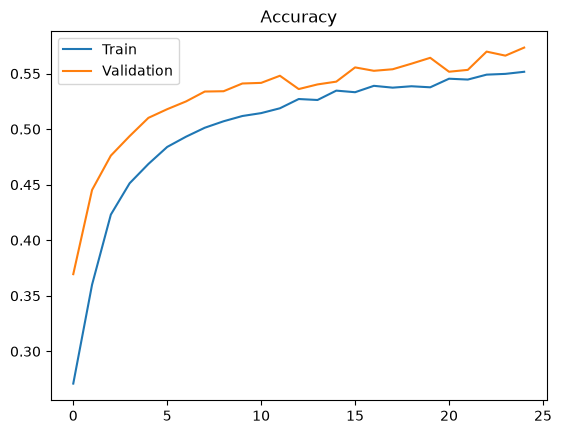

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

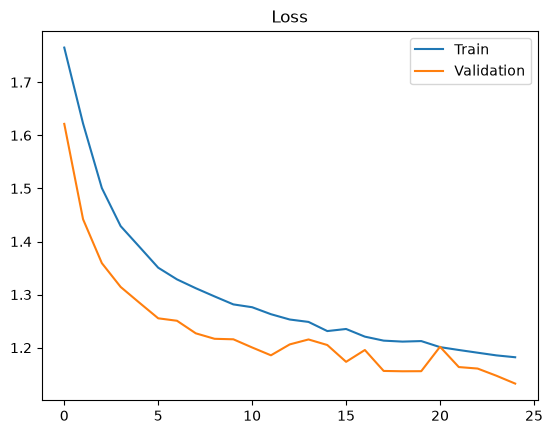

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()

In [33]:
loss,acc=model.evaluate(test_data)

print("Accuracy :",acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5946 - loss: 1.0841
Accuracy : 0.5945945978164673
